In [1]:
# Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, 
                             r2_score, accuracy_score, classification_report)
from xgboost import XGBClassifier, XGBRegressor
import warnings
warnings.filterwarnings('ignore')

print("Tüm kütüphaneler yüklendi!")

Tüm kütüphaneler yüklendi!


In [2]:
# Veri çekimi
df = yf.download("^GSPC", start="2015-01-01", end="2024-12-31")

# Data klasörüne kaydet
df.to_csv('../data/sp500_raw.csv')

print(f"Shape: {df.shape}")
print(f"Tarih aralığı: {df.index[0].date()} → {df.index[-1].date()}")
print(f"Kaydedildi: data/sp500_raw.csv")
print(f"\nEksik değer:\n{df.isnull().sum()}")
df.head()


[*********************100%***********************]  1 of 1 completed

Shape: (2515, 5)
Tarih aralığı: 2015-01-02 → 2024-12-30
Kaydedildi: data/sp500_raw.csv

Eksik değer:
Price   Ticker
Close   ^GSPC     0
High    ^GSPC     0
Low     ^GSPC     0
Open    ^GSPC     0
Volume  ^GSPC     0
dtype: int64


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2015-01-02,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


In [3]:
import sys
sys.path.append('../src')
from features import add_technical_indicators, add_targets

df = add_technical_indicators(df)
df = add_targets(df)
df.dropna(inplace=True)

print(f"Shape: {df.shape}")

Shape: (2315, 20)


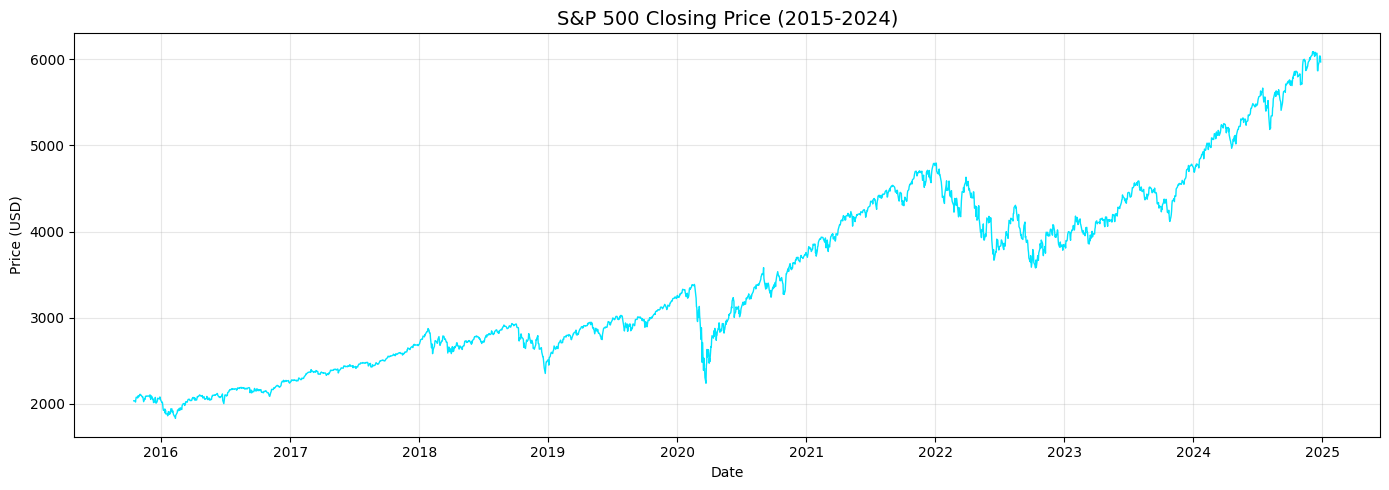

Kaydedildi: outputs/01_closing_price.png


In [4]:
# EDA — Kapanış fiyatı
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='#00e5ff', linewidth=1)
plt.title("S&P 500 Closing Price (2015-2024)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/01_closing_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("Kaydedildi: outputs/01_closing_price.png")


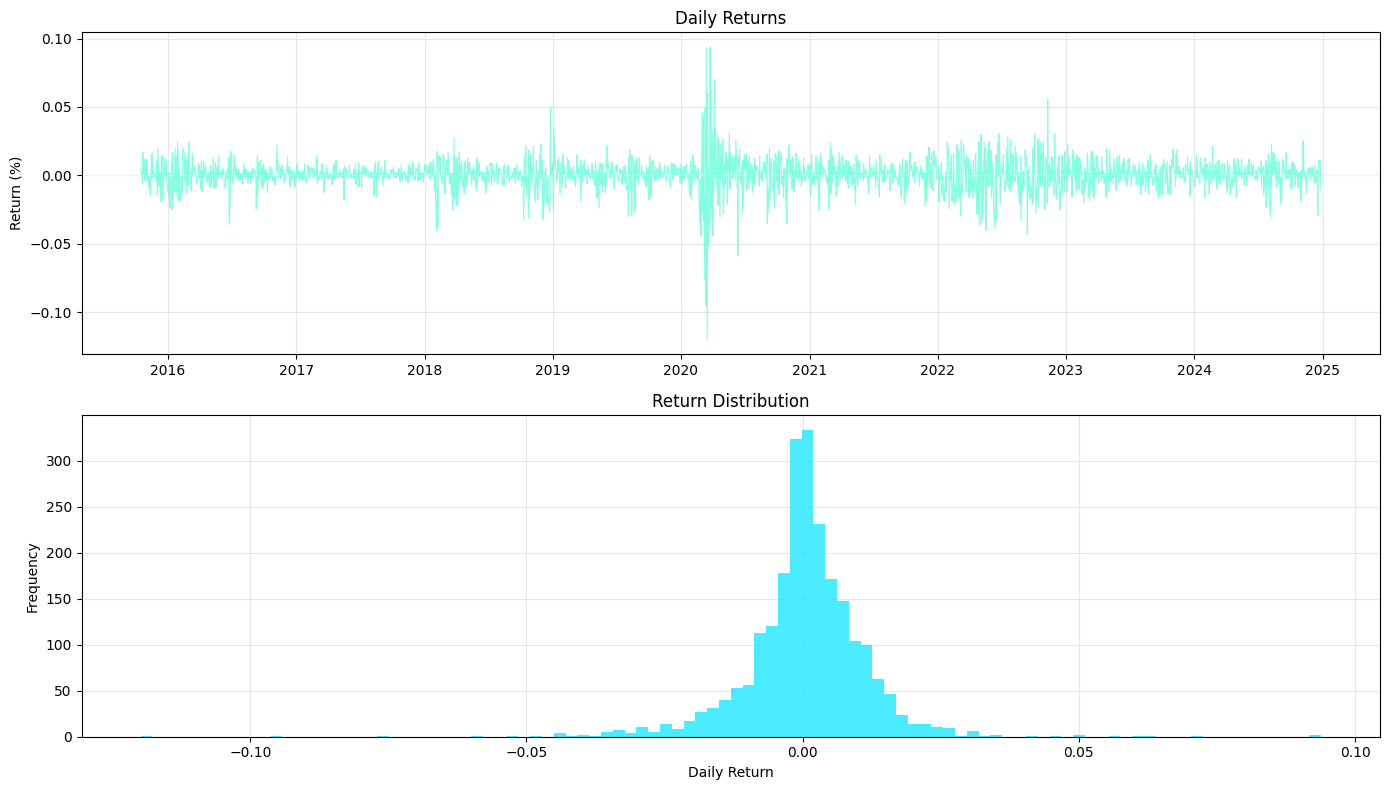

Mean daily return:  0.0005
Std deviation:      0.0113
Worst day: 2020-03-16 → -0.1198
Best day:  2020-03-24 → 0.0938


In [5]:
# EDA — Günlük getiri
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Günlük getiri
axes[0].plot(df.index, df['Daily_Return'], color='#64ffda', linewidth=0.8, alpha=0.8)
axes[0].axhline(y=0, color='white', linewidth=0.5, linestyle='--')
axes[0].set_title("Daily Returns", fontsize=12)
axes[0].set_ylabel("Return (%)")
axes[0].grid(True, alpha=0.3)

# Getiri dağılımı
axes[1].hist(df['Daily_Return'].dropna(), bins=100, color='#00e5ff', alpha=0.7, edgecolor='none')
axes[1].set_title("Return Distribution", fontsize=12)
axes[1].set_xlabel("Daily Return")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/02_daily_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean daily return:  {df['Daily_Return'].mean():.4f}")
print(f"Std deviation:      {df['Daily_Return'].std():.4f}")
print(f"Worst day: {df['Daily_Return'].idxmin().date()} → {df['Daily_Return'].min():.4f}")
print(f"Best day:  {df['Daily_Return'].idxmax().date()} → {df['Daily_Return'].max():.4f}")

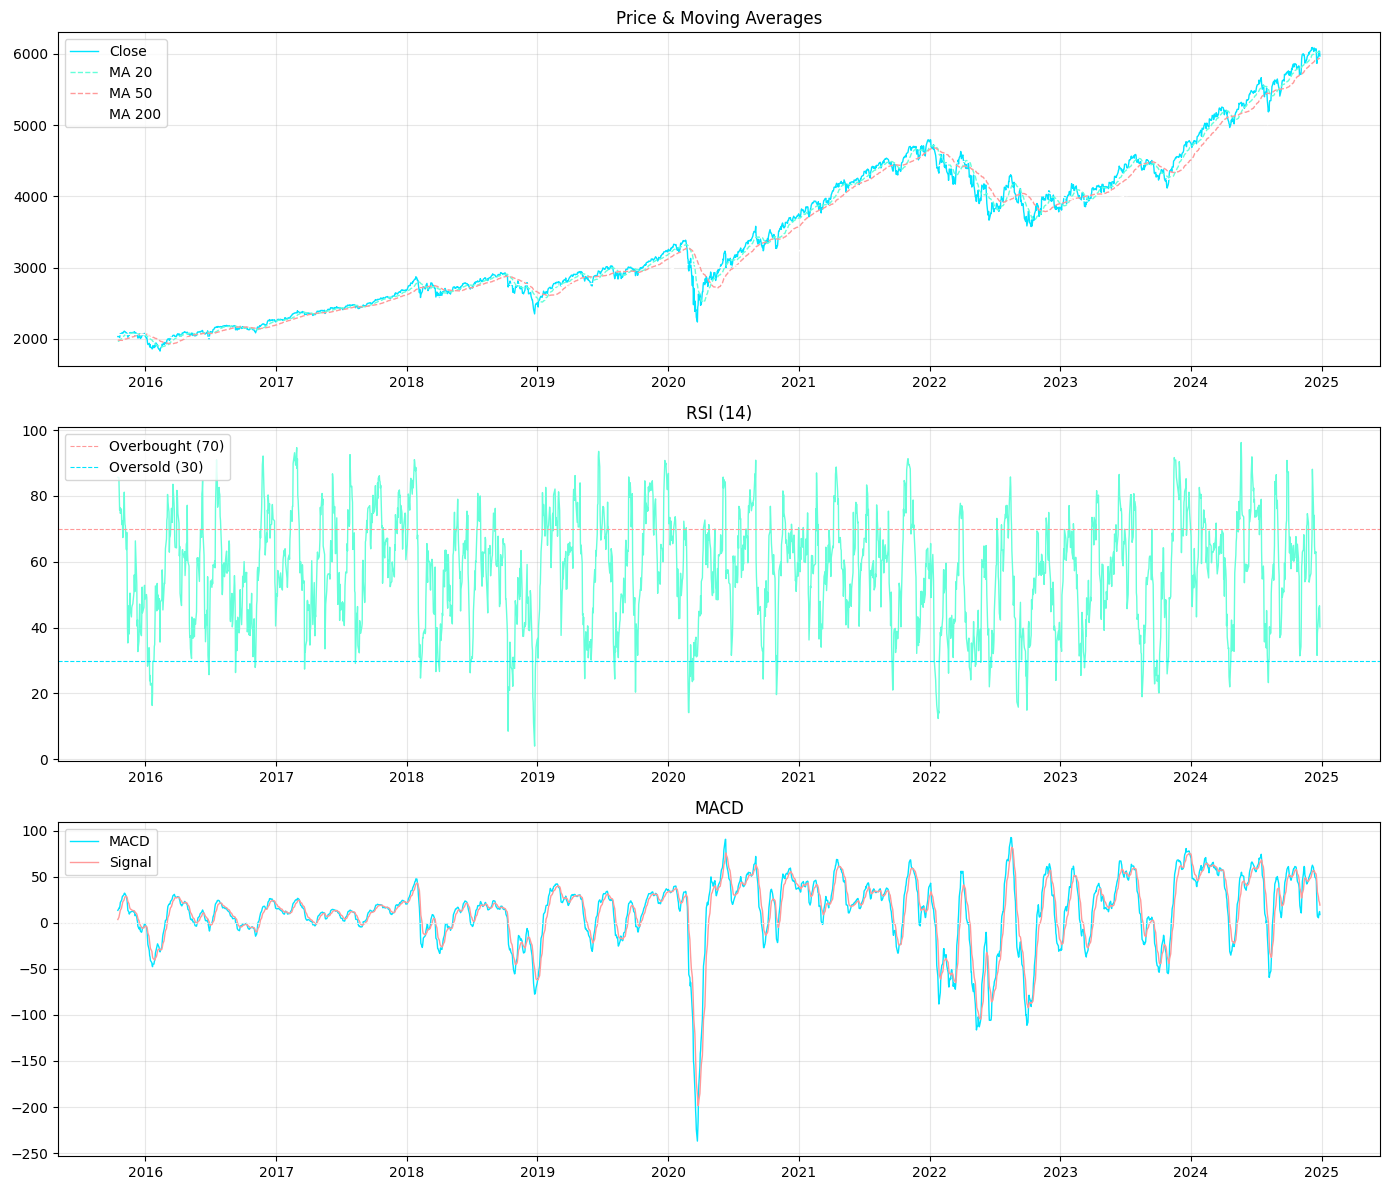

Kaydedildi: outputs/03_technical_indicators.png


In [6]:
# EDA — Teknik indikatörler
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Fiyat + Hareketli Ortalamalar
axes[0].plot(df.index, df['Close'], color='#00e5ff', linewidth=1, label='Close')
axes[0].plot(df.index, df['MA_20'], color='#64ffda', linewidth=1, linestyle='--', label='MA 20')
axes[0].plot(df.index, df['MA_50'], color='#ff9999', linewidth=1, linestyle='--', label='MA 50')
axes[0].plot(df.index, df['MA_200'], color='white', linewidth=1, linestyle='--', label='MA 200')
axes[0].set_title("Price & Moving Averages", fontsize=12)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# RSI
axes[1].plot(df.index, df['RSI'], color='#64ffda', linewidth=1)
axes[1].axhline(y=70, color='#ff9999', linewidth=0.8, linestyle='--', label='Overbought (70)')
axes[1].axhline(y=30, color='#00e5ff', linewidth=0.8, linestyle='--', label='Oversold (30)')
axes[1].set_title("RSI (14)", fontsize=12)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# MACD
axes[2].plot(df.index, df['MACD'], color='#00e5ff', linewidth=1, label='MACD')
axes[2].plot(df.index, df['MACD_Signal'], color='#ff9999', linewidth=1, label='Signal')
axes[2].axhline(y=0, color='white', linewidth=0.5, linestyle='--')
axes[2].set_title("MACD", fontsize=12)
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/03_technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()
print("Kaydedildi: outputs/03_technical_indicators.png")

In [7]:
# Feature listesi ve hedef değişkenler
features = ['Open', 'High', 'Low', 'Close', 'Volume',
            'Daily_Return', 'MA_20', 'MA_50', 'MA_200',
            'Volatility_20', 'RSI', 'MACD', 'MACD_Signal',
            'Lag_1', 'Lag_3', 'Lag_7']

X = df[features]
split = int(len(df) * 0.80)

print(f"Total samples: {len(df)}")
print(f"Train: {split} samples → {df.index[0].date()} to {df.index[split].date()}")
print(f"Test:  {len(df)-split} samples → {df.index[split].date()} to {df.index[-1].date()}")

Total samples: 2315
Train: 1852 samples → 2015-10-16 to 2023-02-27
Test:  463 samples → 2023-02-27 to 2024-12-27


In [8]:
from sklearn.preprocessing import StandardScaler

def prepare_data(df, target_col, features, split):
    """Prepare train/test split with scaling."""
    
    df_copy = df.copy()
    
    X = df_copy[features]
    y = df_copy[target_col]
    
    X_train = X.iloc[:split]
    X_test  = X.iloc[split:]
    y_train = y.iloc[:split]
    y_test  = y.iloc[split:]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# Görev 1 — Yön tahmini
X_train_dir, X_test_dir, y_train_dir, y_test_dir, scaler_dir = prepare_data(
    df, 'Target_Direction', features, split)

# Görev 2 — Fiyat tahmini
X_train_price, X_test_price, y_train_price, y_test_price, scaler_price = prepare_data(
    df, 'Target_Price', features, split)

# Görev 3 — Volatilite tahmini
X_train_vol, X_test_vol, y_train_vol, y_test_vol, scaler_vol = prepare_data(
    df, 'Target_Vol', features, split)

print("Tüm veri setleri hazır!")
print(f"Train shape: {X_train_dir.shape} | Test shape: {X_test_dir.shape}")

Tüm veri setleri hazır!
Train shape: (1852, 16) | Test shape: (463, 16)


In [9]:
import sys
sys.path.append('../src')
from evaluate import regression_metrics, classification_metrics

# Görev 1 — Baseline (çoğunluk sınıfı)
baseline_dir_pred = np.ones(len(y_test_dir), dtype=int)  # hep yükseliş de

baseline_acc = accuracy_score(y_test_dir, baseline_dir_pred)

print("── Baseline (Direction) ─────────────────────")
print(f"Strategy: Always predict 'Up'")
print(f"Accuracy: {baseline_acc:.4f}")
print(f"Up days in test: {y_test_dir.sum()} / {len(y_test_dir)} ({y_test_dir.mean():.2%})")

── Baseline (Direction) ─────────────────────
Strategy: Always predict 'Up'
Accuracy: 0.5637
Up days in test: 261 / 463 (56.37%)


In [10]:
from xgboost import XGBClassifier

# Görev 1 — XGBoost
xgb_dir = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_dir.fit(X_train_dir, y_train_dir)
xgb_dir_pred = xgb_dir.predict(X_test_dir)

print("── XGBoost (Direction) ──────────────────────")
print(f"Accuracy: {accuracy_score(y_test_dir, xgb_dir_pred):.4f}")
print()
print(classification_report(y_test_dir, xgb_dir_pred, 
                            target_names=['Down', 'Up']))

── XGBoost (Direction) ──────────────────────
Accuracy: 0.4924

              precision    recall  f1-score   support

        Down       0.45      0.68      0.54       202
          Up       0.58      0.34      0.43       261

    accuracy                           0.49       463
   macro avg       0.52      0.51      0.49       463
weighted avg       0.52      0.49      0.48       463



In [11]:
from sklearn.ensemble import RandomForestClassifier

# Görev 1 — Random Forest
rf_dir = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

rf_dir.fit(X_train_dir, y_train_dir)
rf_dir_pred = rf_dir.predict(X_test_dir)

print("── Random Forest (Direction) ────────────────")
print(f"Accuracy: {accuracy_score(y_test_dir, rf_dir_pred):.4f}")
print()
print(classification_report(y_test_dir, rf_dir_pred,
                            target_names=['Down', 'Up']))

── Random Forest (Direction) ────────────────
Accuracy: 0.4795

              precision    recall  f1-score   support

        Down       0.43      0.59      0.50       202
          Up       0.55      0.39      0.46       261

    accuracy                           0.48       463
   macro avg       0.49      0.49      0.48       463
weighted avg       0.50      0.48      0.48       463



In [13]:
# Görev 2 — Baseline (dünün fiyatı)
baseline_price_pred = df['Close'].iloc[split:split + len(y_test_price)].values

baseline_price_rmse = np.sqrt(mean_squared_error(y_test_price, baseline_price_pred))
baseline_price_mae = mean_absolute_error(y_test_price, baseline_price_pred)
baseline_price_r2 = r2_score(y_test_price, baseline_price_pred)

print("── Baseline (Price) ─────────────────────────")
print(f"RMSE: {baseline_price_rmse:.2f}")
print(f"MAE:  {baseline_price_mae:.2f}")
print(f"R²:   {baseline_price_r2:.4f}")

── Baseline (Price) ─────────────────────────
RMSE: 39.27
MAE:  29.47
R²:   0.9961


In [14]:
from xgboost import XGBRegressor

# Görev 2 — XGBoost
xgb_price = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_price.fit(X_train_price, y_train_price)
xgb_price_pred = xgb_price.predict(X_test_price)

xgb_price_rmse = np.sqrt(mean_squared_error(y_test_price, xgb_price_pred))
xgb_price_mae = mean_absolute_error(y_test_price, xgb_price_pred)
xgb_price_r2 = r2_score(y_test_price, xgb_price_pred)

print("── XGBoost (Price) ──────────────────────────")
print(f"RMSE: {xgb_price_rmse:.2f}")
print(f"MAE:  {xgb_price_mae:.2f}")
print(f"R²:   {xgb_price_r2:.4f}")

── XGBoost (Price) ──────────────────────────
RMSE: 629.61
MAE:  430.40
R²:   -0.0115


In [15]:
from sklearn.ensemble import RandomForestRegressor

# Görev 2 — Random Forest
rf_price = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

rf_price.fit(X_train_price, y_train_price)
rf_price_pred = rf_price.predict(X_test_price)

rf_price_rmse = np.sqrt(mean_squared_error(y_test_price, rf_price_pred))
rf_price_mae = mean_absolute_error(y_test_price, rf_price_pred)
rf_price_r2 = r2_score(y_test_price, rf_price_pred)

print("── Random Forest (Price) ────────────────────")
print(f"RMSE: {rf_price_rmse:.2f}")
print(f"MAE:  {rf_price_mae:.2f}")
print(f"R²:   {rf_price_r2:.4f}")

── Random Forest (Price) ────────────────────
RMSE: 588.74
MAE:  398.77
R²:   0.1155


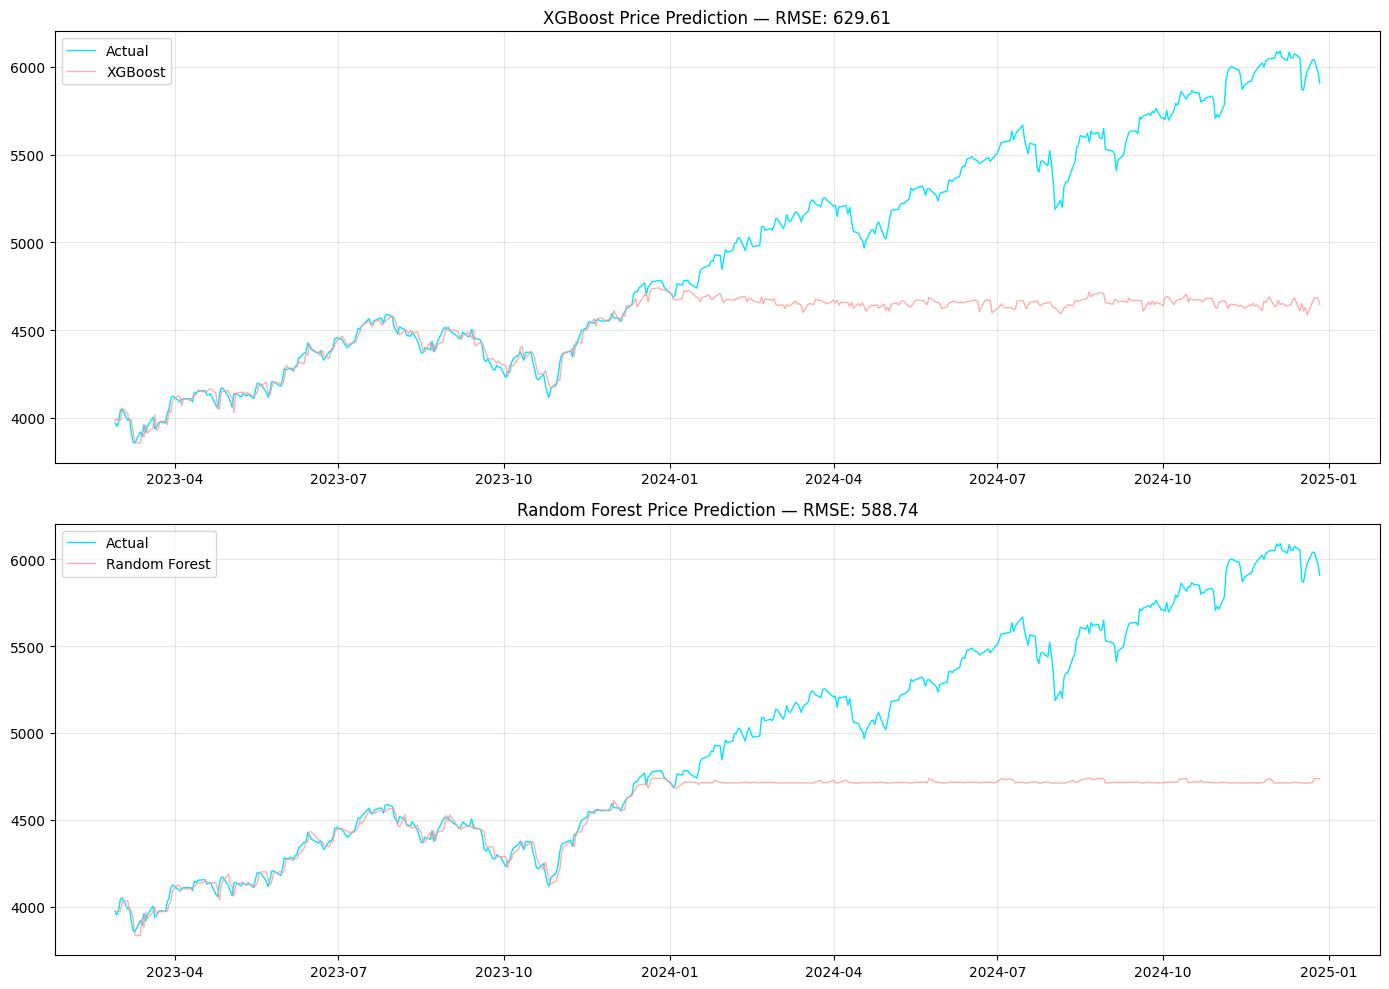

Kaydedildi: outputs/04_price_prediction.png


In [16]:
test_dates = df.index[split:]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# XGBoost
axes[0].plot(test_dates, y_test_price.values, color='#00e5ff', linewidth=1, label='Actual')
axes[0].plot(test_dates, xgb_price_pred, color='#ff9999', linewidth=1, label='XGBoost', alpha=0.8)
axes[0].set_title(f"XGBoost Price Prediction — RMSE: {xgb_price_rmse:.2f}", fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].plot(test_dates, y_test_price.values, color='#00e5ff', linewidth=1, label='Actual')
axes[1].plot(test_dates, rf_price_pred, color='#ff9999', linewidth=1, label='Random Forest', alpha=0.8)
axes[1].set_title(f"Random Forest Price Prediction — RMSE: {rf_price_rmse:.2f}", fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/04_price_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Kaydedildi: outputs/04_price_prediction.png")

In [17]:
# Görev 3 — Baseline (dünün volatilitesi)
baseline_vol_pred = df['Volatility_20'].iloc[split:split + len(y_test_vol)].values

baseline_vol_rmse = np.sqrt(mean_squared_error(y_test_vol, baseline_vol_pred))
baseline_vol_mae = mean_absolute_error(y_test_vol, baseline_vol_pred)
baseline_vol_r2 = r2_score(y_test_vol, baseline_vol_pred)

print("── Baseline (Volatility) ────────────────────")
print(f"RMSE: {baseline_vol_rmse:.6f}")
print(f"MAE:  {baseline_vol_mae:.6f}")
print(f"R²:   {baseline_vol_r2:.4f}")

── Baseline (Volatility) ────────────────────
RMSE: 0.000472
MAE:  0.000285
R²:   0.9441


In [18]:
# Görev 3 — XGBoost
xgb_vol = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_vol.fit(X_train_vol, y_train_vol)
xgb_vol_pred = xgb_vol.predict(X_test_vol)

xgb_vol_rmse = np.sqrt(mean_squared_error(y_test_vol, xgb_vol_pred))
xgb_vol_mae = mean_absolute_error(y_test_vol, xgb_vol_pred)
xgb_vol_r2 = r2_score(y_test_vol, xgb_vol_pred)

print("── XGBoost (Volatility) ─────────────────────")
print(f"RMSE: {xgb_vol_rmse:.6f}")
print(f"MAE:  {xgb_vol_mae:.6f}")
print(f"R²:   {xgb_vol_r2:.4f}")

── XGBoost (Volatility) ─────────────────────
RMSE: 0.000645
MAE:  0.000479
R²:   0.8958


In [19]:
# Görev 3 — Random Forest
rf_vol = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

rf_vol.fit(X_train_vol, y_train_vol)
rf_vol_pred = rf_vol.predict(X_test_vol)

rf_vol_rmse = np.sqrt(mean_squared_error(y_test_vol, rf_vol_pred))
rf_vol_mae = mean_absolute_error(y_test_vol, rf_vol_pred)
rf_vol_r2 = r2_score(y_test_vol, rf_vol_pred)

print("── Random Forest (Volatility) ───────────────")
print(f"RMSE: {rf_vol_rmse:.6f}")
print(f"MAE:  {rf_vol_mae:.6f}")
print(f"R²:   {rf_vol_r2:.4f}")

── Random Forest (Volatility) ───────────────
RMSE: 0.000493
MAE:  0.000318
R²:   0.9390


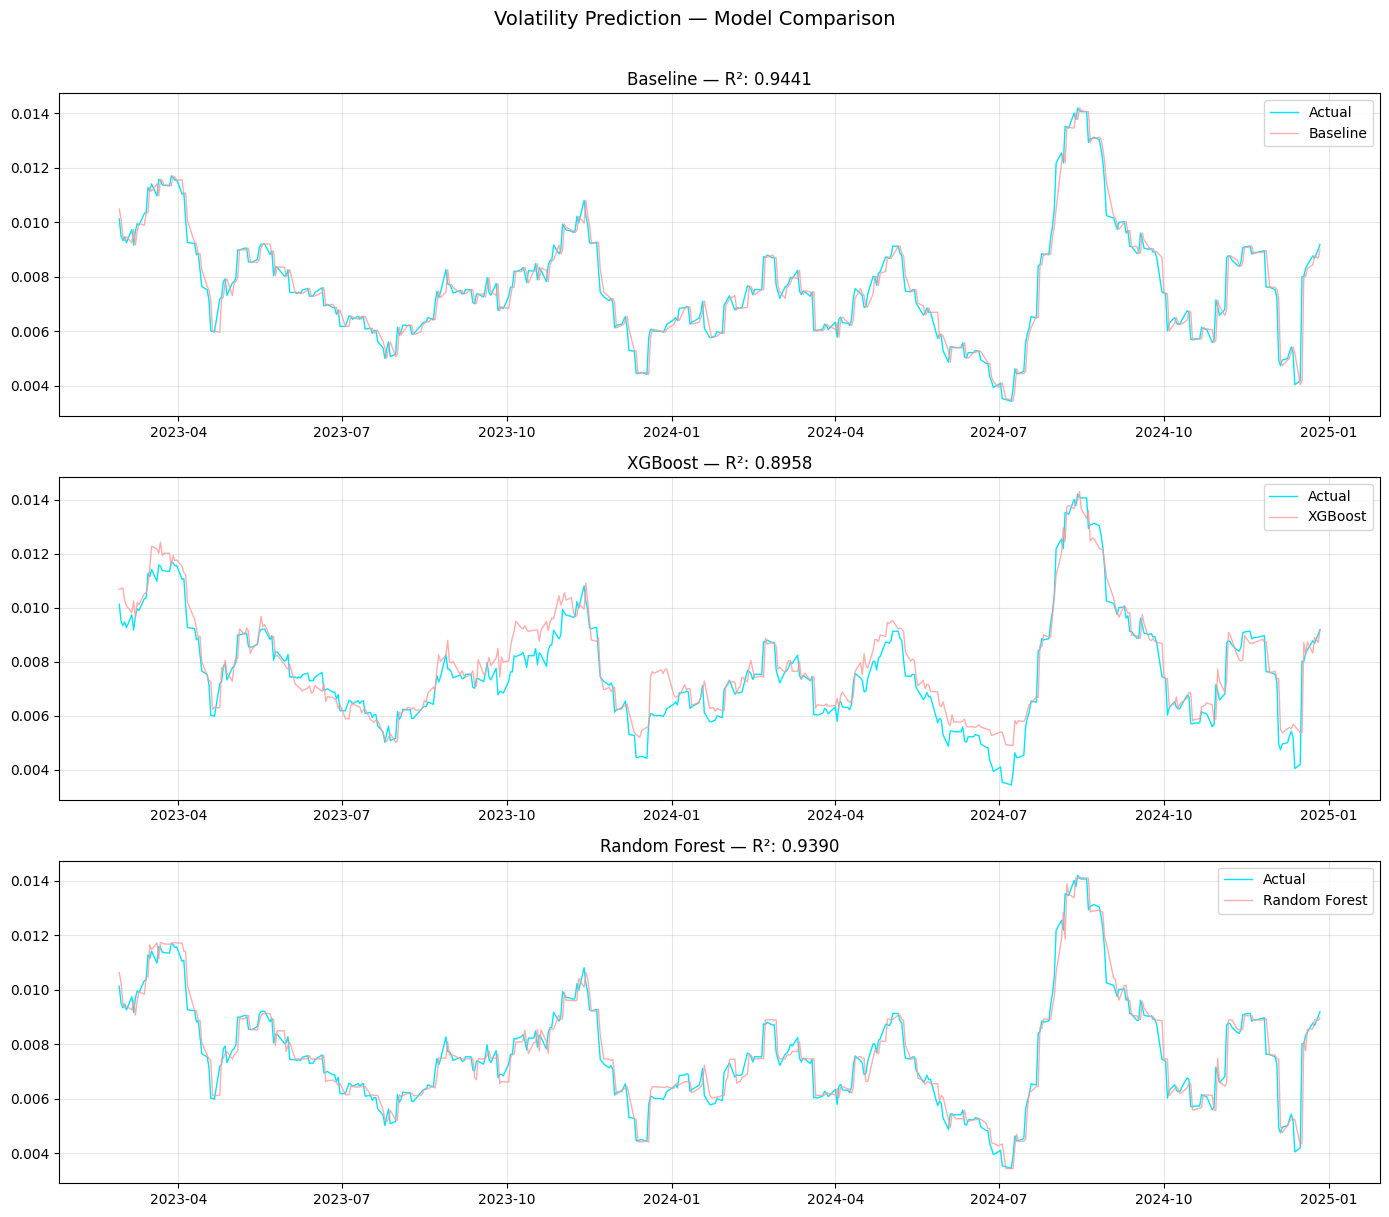

Kaydedildi: outputs/05_volatility_prediction.png


In [20]:
test_dates = df.index[split:]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Baseline
axes[0].plot(test_dates, y_test_vol.values, color='#00e5ff', linewidth=1, label='Actual')
axes[0].plot(test_dates, baseline_vol_pred, color='#ff9999', linewidth=1, label='Baseline', alpha=0.8)
axes[0].set_title(f"Baseline — R²: 0.9441", fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# XGBoost
axes[1].plot(test_dates, y_test_vol.values, color='#00e5ff', linewidth=1, label='Actual')
axes[1].plot(test_dates, xgb_vol_pred, color='#ff9999', linewidth=1, label='XGBoost', alpha=0.8)
axes[1].set_title(f"XGBoost — R²: 0.8958", fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Random Forest
axes[2].plot(test_dates, y_test_vol.values, color='#00e5ff', linewidth=1, label='Actual')
axes[2].plot(test_dates, rf_vol_pred, color='#ff9999', linewidth=1, label='Random Forest', alpha=0.8)
axes[2].set_title(f"Random Forest — R²: 0.9390", fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Volatility Prediction — Model Comparison", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/05_volatility_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Kaydedildi: outputs/05_volatility_prediction.png")